# Sonar Rock vs. Mine Prediction

## Project Overview
This project focuses on a binary classification problem: distinguishing between **Rocks** and **Naval Mines** using sonar signal data.

### 🔍 The Dataset
The dataset contains 208 patterns obtained by bouncing sonar signals off a metal cylinder (mine) and a rough cylindrical rock at various angles and under different conditions.
* **Input Features:** 60 numerical attributes representing the energy within a particular frequency band.
* **Target Label:** 'R' (Rock) or 'M' (Mine).

### 🎯 Objective
To build a robust machine learning model that can accurately classify new sonar readings as either a rock or a mine, aiming for high accuracy and minimal false negatives.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Warnings removal
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Load and explore data
file_path = 'Sonar_dataset.csv'
solar_df = pd.read_csv(file_path, header=None)
print(solar_df.head())

       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.0032   R  
1  0.0052  0.0044   R  
2  0.0095  0.0078   

In [3]:
# Basic info about columns, types, and missing values
print(solar_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null    float64
 22  22

In [4]:
# Dataset shape
print(f"Number of rows: {solar_df.shape[0]}, Number of columns: {solar_df.shape[1]}")

Number of rows: 208, Number of columns: 61


## 3. Exploratory Data Analysis (EDA)
Before training, I have visualized the data to understand class balance and feature correlations.
* **Class Balance:** Checks if it has enough examples of both Rocks and Mines.
* **Correlation:** Checks if specific frequency bands are strongly correlated with the object type.

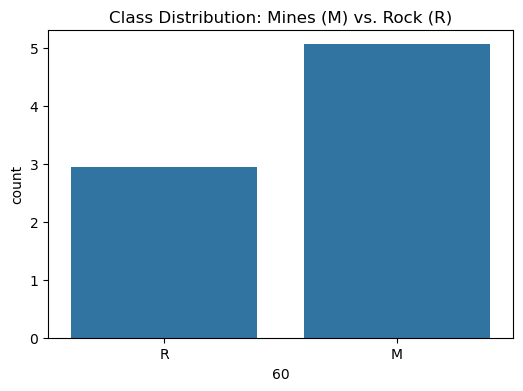

In [5]:
# Separating target values
target_values = solar_df[60]

# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x=target_values, data=solar_df)
plt.title('Class Distribution: Mines (M) vs. Rock (R)')
plt.show()

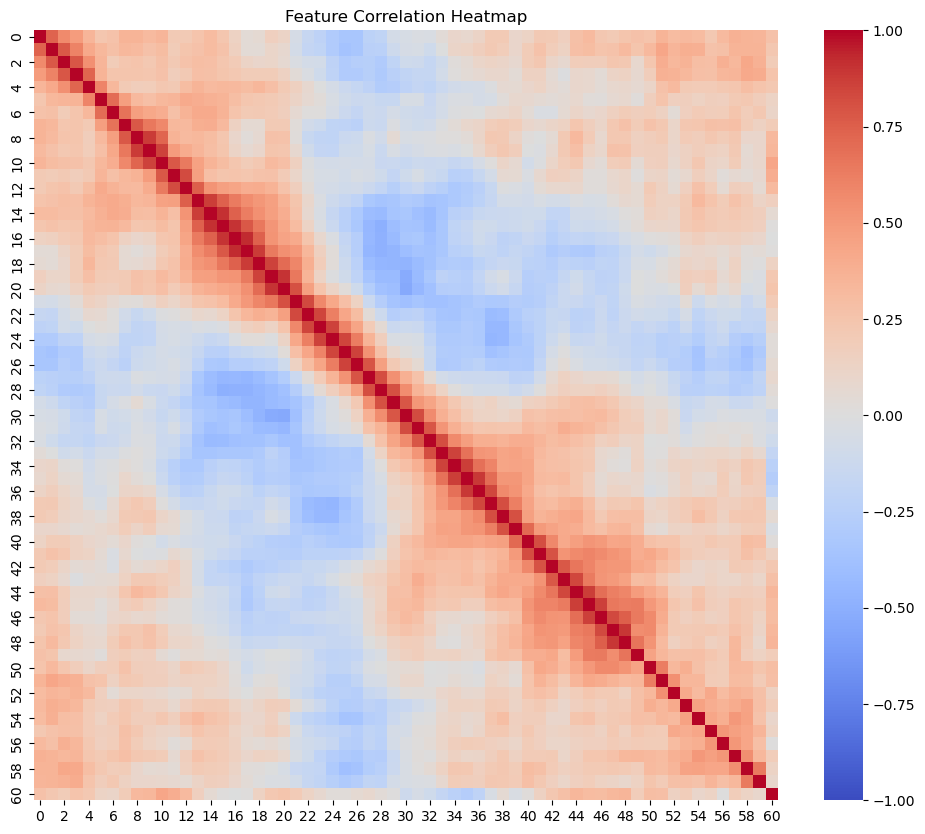

In [6]:
# Correlation Heatmap
plot_df = solar_df.copy()
plot_df[60] = plot_df[60].map({'R': 0, 'M': 1})
plt.figure(figsize=(12,10))
correlation = plot_df.corr()
sns.heatmap(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Model Training & Hyperparameter Tuning
I have used a **Support Vector Machine (SVM)** for this task. Why? Because SVMs are generally more effective than Logistic Regression for high-dimensional data (60 features) with complex boundaries.

### Optimization with GridSearchCV
Instead of guessing parameters, i used `GridSearchCV` to automatically test multiple combinations of:
* `C` (Regularization parameter)
* `kernel` (Linear vs. Non-linear boundaries)
* `gamma` (Kernel coefficient)

In [8]:
X = solar_df.drop(columns=[60], axis=1)
y = solar_df[60]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, stratify=y, random_state=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {'C': [0.1, 1, 10, 100], 
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly']
             }

grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose = 2)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters found: {grid_search.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.

In [9]:
best_model = grid_search.best_estimator_
train_pred = best_model.predict(X_train_scaled)
test_pred = best_model.predict(X_test_scaled)

print('Accuracy on Test data:' , accuracy_score(y_test, test_pred))
print('\n Classification Report:\n', classification_report(y_test, test_pred))

Accuracy on Test data: 0.9523809523809523

 Classification Report:
               precision    recall  f1-score   support

           M       0.92      1.00      0.96        11
           R       1.00      0.90      0.95        10

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



In [10]:
def make_batch_predictions(input_csv_path, output_csv_path, model, scaler):
    try:
        # Load new data (Assuming it has no header and 60 columns like training data)
        new_data = pd.read_csv(input_csv_path, header=None)
        
        # Check shape
        if new_data.shape[1] != 60:
            print(f"Error: Input file has {new_data.shape[1]} columns. Expected 60.")
            return

        # Scale the data using the SAME scaler from training
        new_data_scaled = scaler.transform(new_data)
        
        # Predict
        predictions = model.predict(new_data_scaled)
        
        # Add predictions to the dataframe
        new_data['Prediction'] = predictions
        
        # Save to CSV
        new_data.to_csv(output_csv_path, index=False)
        print(f"Success! Predictions saved to {output_csv_path}")
        
        # Display first few rows
        print(new_data.head())
        
    except Exception as e:
        print(f"An error occurred: {e}")

# Example Usage:
# Since we don't have a new file, let's create a dummy one from our test set to test the function
X_test.to_csv('dummy_new_sonar_data.csv', index=False, header=False)

# Run the function
make_batch_predictions('dummy_new_sonar_data.csv', 'prediction_results.csv', best_model, scaler)

Success! Predictions saved to prediction_results.csv
        0       1       2       3       4       5       6       7       8  \
0  0.0283  0.0599  0.0656  0.0229  0.0839  0.1673  0.1154  0.1098  0.1370   
1  0.0115  0.0150  0.0136  0.0076  0.0211  0.1058  0.1023  0.0440  0.0931   
2  0.0408  0.0653  0.0397  0.0604  0.0496  0.1817  0.1178  0.1024  0.0583   
3  0.0100  0.0194  0.0155  0.0489  0.0839  0.1009  0.1627  0.2071  0.2696   
4  0.0409  0.0421  0.0573  0.0130  0.0183  0.1019  0.1054  0.1070  0.2302   

        9  ...      51      52      53      54      55      56      57  \
0  0.1767  ...  0.0147  0.0170  0.0158  0.0046  0.0073  0.0054  0.0033   
1  0.0734  ...  0.0091  0.0016  0.0084  0.0064  0.0026  0.0029  0.0037   
2  0.2176  ...  0.0062  0.0129  0.0184  0.0069  0.0198  0.0199  0.0102   
3  0.2990  ...  0.0130  0.0073  0.0077  0.0075  0.0060  0.0080  0.0019   
4  0.2259  ...  0.0028  0.0036  0.0105  0.0120  0.0087  0.0061  0.0061   

       58      59  Prediction  
0  0.00